# Customer Churn Prediction using Machine Learning

## Project Overview

This project aims to predict whether a customer is likely to churn using machine learning techniques.

The project includes data preprocessing, exploratory data analysis, feature encoding, model training, evaluation, feature importance analysis, and model comparison.

In [2]:
import pandas as pd

df = pd.read_csv("/content/churn-bigml-80.csv")

print(df.head())
print(df.shape)
print(df.info())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [7]:
# Check missing values
df.isnull().sum()


,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

,0
State,object
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64


In [10]:
df.nunique()

,0
State,51
Account length,205
Area code,3
International plan,2
Voice mail plan,2
Number vmail messages,42
Total day minutes,1489
Total day calls,115
Total day charge,1489
Total eve minutes,1442


In [11]:
# Check unique values in categorical columns

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


State:
['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'WV' 'RI' 'IA' 'MT' 'ID' 'VT' 'VA'
 'TX' 'FL' 'CO' 'AZ' 'NE' 'WY' 'IL' 'NH' 'LA' 'GA' 'AK' 'MD' 'AR' 'WI'
 'OR' 'DE' 'IN' 'UT' 'CA' 'SD' 'NC' 'WA' 'MN' 'NM' 'NV' 'DC' 'NY' 'KY'
 'ME' 'MS' 'MI' 'SC' 'TN' 'PA' 'HI' 'ND' 'CT']

International plan:
['No' 'Yes']

Voice mail plan:
['Yes' 'No']


In [12]:
# Check missing values
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [13]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [14]:
# Check for negative values in numerical columns

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    print(col, ":", (df[col] < 0).sum())

Account length : 0
Area code : 0
Number vmail messages : 0
Total day minutes : 0
Total day calls : 0
Total day charge : 0
Total eve minutes : 0
Total eve calls : 0
Total eve charge : 0
Total night minutes : 0
Total night calls : 0
Total night charge : 0
Total intl minutes : 0
Total intl calls : 0
Total intl charge : 0
Customer service calls : 0


In [15]:
# Churn distribution

print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
False    2278
True      388
Name: count, dtype: int64

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


In [16]:
pd.crosstab(df['International plan'], df['Churn'], normalize='index') * 100

Churn,False,True
International plan,,
No,88.731219,11.268781
Yes,56.296296,43.703704


In [17]:
pd.crosstab(df['Voice mail plan'], df['Churn'], normalize='index') * 100

Churn,False,True
Voice mail plan,,
No,83.290222,16.709778
Yes,91.132333,8.867667


In [18]:
df.groupby('Churn')['Total day minutes'].mean()

,Total day minutes
Churn,
False,175.104346
True,205.181186


In [19]:
df.groupby('Churn')['Total eve minutes'].mean()

,Total eve minutes
Churn,
False,198.853380
True,209.385309


In [20]:
df.groupby('Churn')['Total night minutes'].mean()

,Total night minutes
Churn,
False,200.464091
True,205.307216


In [21]:
df.groupby('Churn')['Total intl minutes'].mean()

,Total intl minutes
Churn,
False,10.13784
True,10.81933


In [22]:
df.groupby('Churn')['Customer service calls'].mean()

,Customer service calls
Churn,
False,1.453029
True,2.206186


In [23]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
Customer service calls,0.202590
Total day charge,0.195689
Total day minutes,0.195688
Total intl charge,0.086216
Total intl minutes,0.086204
Total eve minutes,0.072906
Total eve charge,0.072893
Total night minutes,0.033639
Total night charge,0.033635


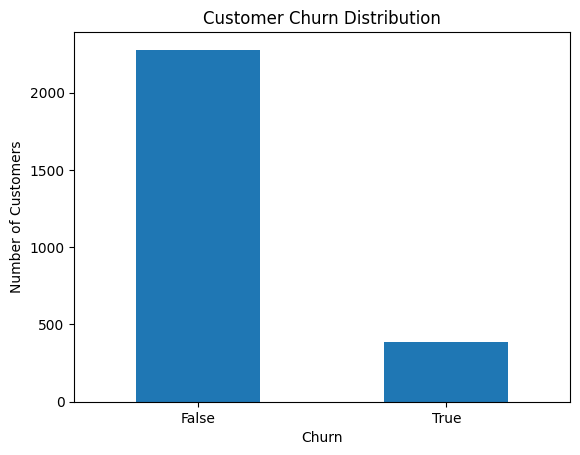

In [24]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

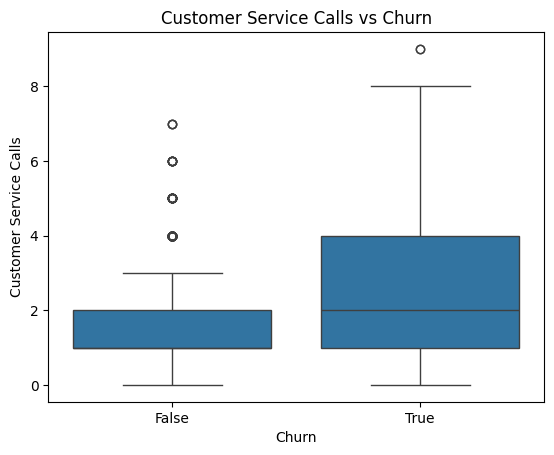

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='Customer service calls', data=df)

plt.title('Customer Service Calls vs Churn')
plt.xlabel('Churn')
plt.ylabel('Customer Service Calls')
plt.show()

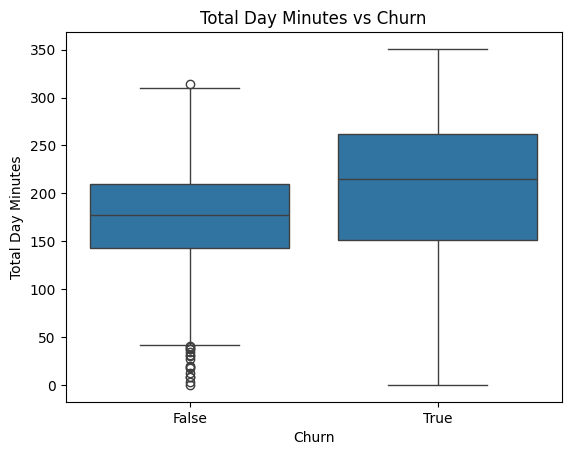

In [26]:
sns.boxplot(x='Churn', y='Total day minutes', data=df)

plt.title('Total Day Minutes vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Day Minutes')
plt.show()

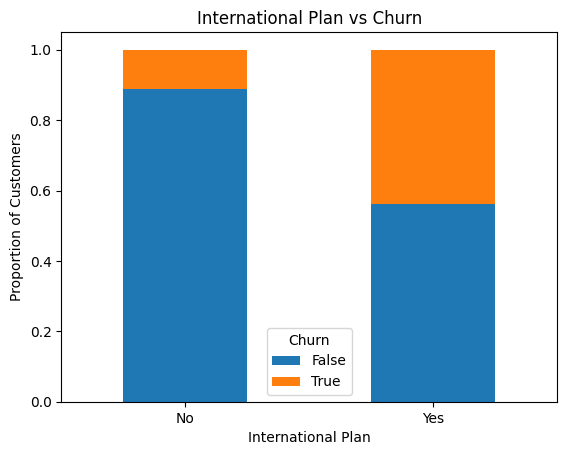

In [27]:
pd.crosstab(
    df['International plan'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('International Plan vs Churn')
plt.xlabel('International Plan')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

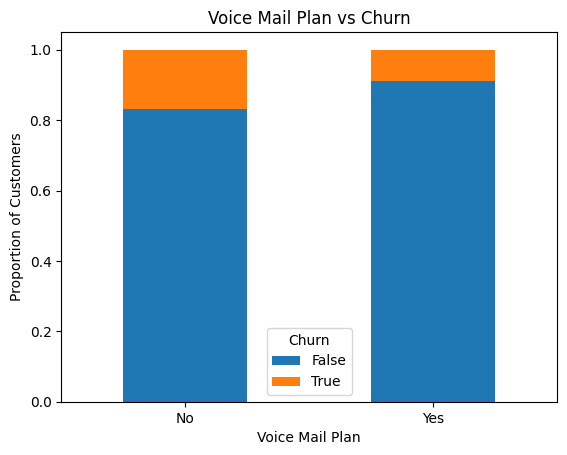

In [28]:
pd.crosstab(
    df['Voice mail plan'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Voice Mail Plan vs Churn')
plt.xlabel('Voice Mail Plan')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [29]:
# Convert Churn to numeric
df['Churn_numeric'] = df['Churn'].astype(int)

# Correlation with Churn
correlation = df.corr(numeric_only=True)['Churn_numeric'].sort_values(ascending=False)

print(correlation)

Churn                     1.000000
Churn_numeric             1.000000
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Name: Churn_numeric, dtype: float64


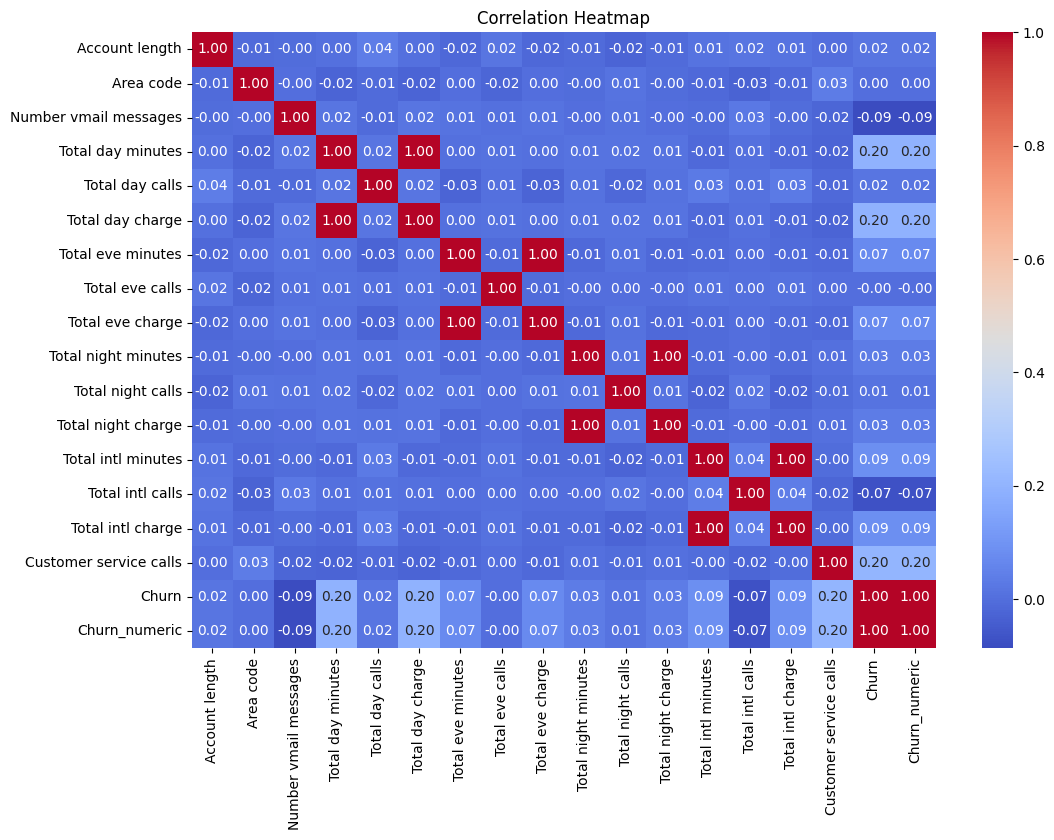

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [31]:
# Remove temporary column
df = df.drop(columns=['Churn_numeric'])

# Check columns
print(df.columns)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


In [32]:
# Check categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['State', 'International plan', 'Voice mail plan'], dtype='object')


In [33]:
# Encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=['State', 'International plan', 'Voice mail plan'],
    drop_first=True
)

# Convert boolean columns to integers
df_encoded = df_encoded.astype(int)

print(df_encoded.shape)
print(df_encoded.head())

(2666, 69)
   Account length  Area code  Number vmail messages  Total day minutes  \
0             128        415                     25                265   
1             107        415                     26                161   
2             137        415                      0                243   
3              84        408                      0                299   
4              75        415                      0                166   

   Total day calls  Total day charge  Total eve minutes  Total eve calls  \
0              110                45                197               99   
1              123                27                195              103   
2              114                41                121              110   
3               71                50                 61               88   
4              113                28                148              122   

   Total eve charge  Total night minutes  ...  State_TX  State_UT  State_VA  \
0       

In [34]:
# Separate features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2666, 68)
y shape: (2666,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2132, 68)
X_test: (534, 68)
y_train: (2132,)
y_test: (534,)


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
# Make predictions
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8445692883895131
Accuracy (%): 84.45692883895131


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[435  21]
 [ 62  16]]


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       456
           1       0.43      0.21      0.28        78

    accuracy                           0.84       534
   macro avg       0.65      0.58      0.60       534
weighted avg       0.81      0.84      0.82       534



In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [42]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

print("Scaled model trained successfully!")

Scaled model trained successfully!


In [43]:
# Make predictions using scaled model
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Predictions:", y_pred_scaled[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]


In [44]:
from sklearn.metrics import accuracy_score

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Scaled Model Accuracy:", accuracy_scaled)
print("Scaled Model Accuracy (%):", accuracy_scaled * 100)

Scaled Model Accuracy: 0.8520599250936329
Scaled Model Accuracy (%): 85.2059925093633


In [45]:
from sklearn.metrics import confusion_matrix, classification_report

cm_scaled = confusion_matrix(y_test, y_pred_scaled)

print("Confusion Matrix:")
print(cm_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Confusion Matrix:
[[435  21]
 [ 58  20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       456
           1       0.49      0.26      0.34        78

    accuracy                           0.85       534
   macro avg       0.69      0.61      0.63       534
weighted avg       0.82      0.85      0.83       534



In [46]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced model trained successfully!")

Balanced model trained successfully!


In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

print("Balanced Model Accuracy:", accuracy_balanced)
print("Balanced Model Accuracy (%):", accuracy_balanced * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Accuracy: 0.7434456928838952
Balanced Model Accuracy (%): 74.34456928838952

Confusion Matrix:
[[349 107]
 [ 30  48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       456
           1       0.31      0.62      0.41        78

    accuracy                           0.74       534
   macro avg       0.62      0.69      0.62       534
weighted avg       0.83      0.74      0.77       534



In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Accuracy (%):", accuracy_rf * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9213483146067416
Random Forest Accuracy (%): 92.13483146067416

Confusion Matrix:
[[456   0]
 [ 42  36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       456
           1       1.00      0.46      0.63        78

    accuracy                           0.92       534
   macro avg       0.96      0.73      0.79       534
weighted avg       0.93      0.92      0.91       534



In [50]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                   Feature  Importance
3        Total day minutes    0.133327
15  Customer service calls    0.125429
5         Total day charge    0.104400
66  International plan_Yes    0.083656
6        Total eve minutes    0.053211
9      Total night minutes    0.046155
10       Total night calls    0.039824
4          Total day calls    0.039809
0           Account length    0.038886
8         Total eve charge    0.038588
7          Total eve calls    0.037334
13        Total intl calls    0.037169
12      Total intl minutes    0.033573
11      Total night charge    0.025000
2    Number vmail messages    0.024469


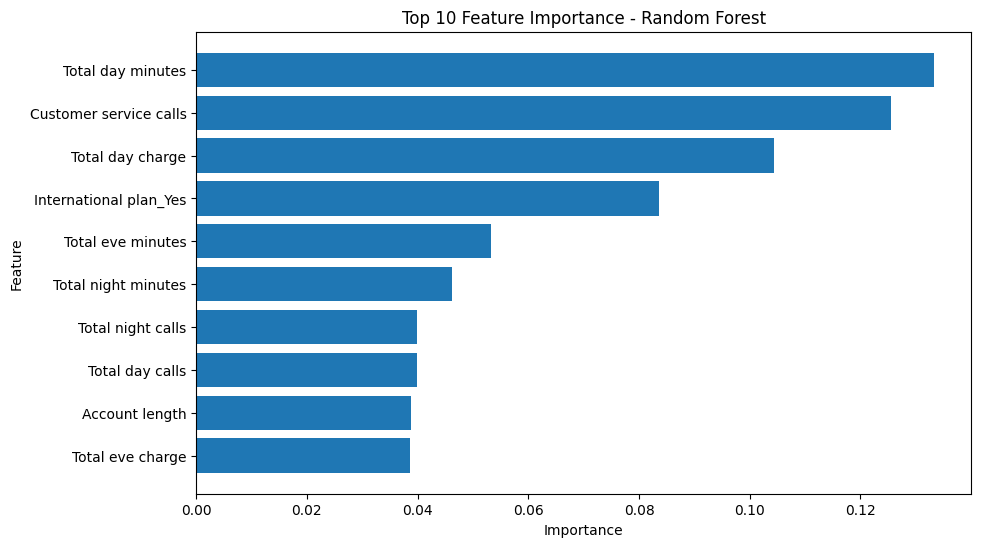

In [51]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [52]:
from sklearn.metrics import accuracy_score

print("Model Comparison")
print("-------------------------")
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Scaled Logistic Regression:", accuracy_score(y_test, y_pred_scaled))
print("Balanced Logistic Regression:", accuracy_score(y_test, y_pred_balanced))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Model Comparison
-------------------------
Logistic Regression: 0.8445692883895131
Scaled Logistic Regression: 0.8520599250936329
Balanced Logistic Regression: 0.7434456928838952
Random Forest: 0.9213483146067416


In [53]:
import joblib

joblib.dump(rf_model, "churn_random_forest_model.pkl")
joblib.dump(scaler, "churn_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


# Final Conclusion

Multiple machine learning models were trained and evaluated to predict customer churn.

- Logistic Regression Accuracy: 84.46%
- Scaled Logistic Regression Accuracy: 85.21%
- Balanced Logistic Regression Accuracy: 74.34%
- Random Forest Accuracy: 92.13%

The Random Forest model achieved the highest overall accuracy and was selected as the final model.

Feature importance analysis showed that Total day minutes, Customer service calls, Total day charge, and International plan were among the most important features for predicting customer churn.

## Business Insights

- Customers with high total day minutes are important for churn prediction.
- Customer service calls are an important churn-related feature.
- International plan is also influential.
- The company can identify high-risk customers and take early retention actions.

## Model Performance

| Model | Accuracy |
|---|---:|
| Logistic Regression | 84.46% |
| Scaled Logistic Regression | 85.21% |
| Balanced Logistic Regression | 74.34% |
| Random Forest | 92.13% |

### Best Model
Random Forest achieved the highest overall accuracy of **92.13%** among the models tested.